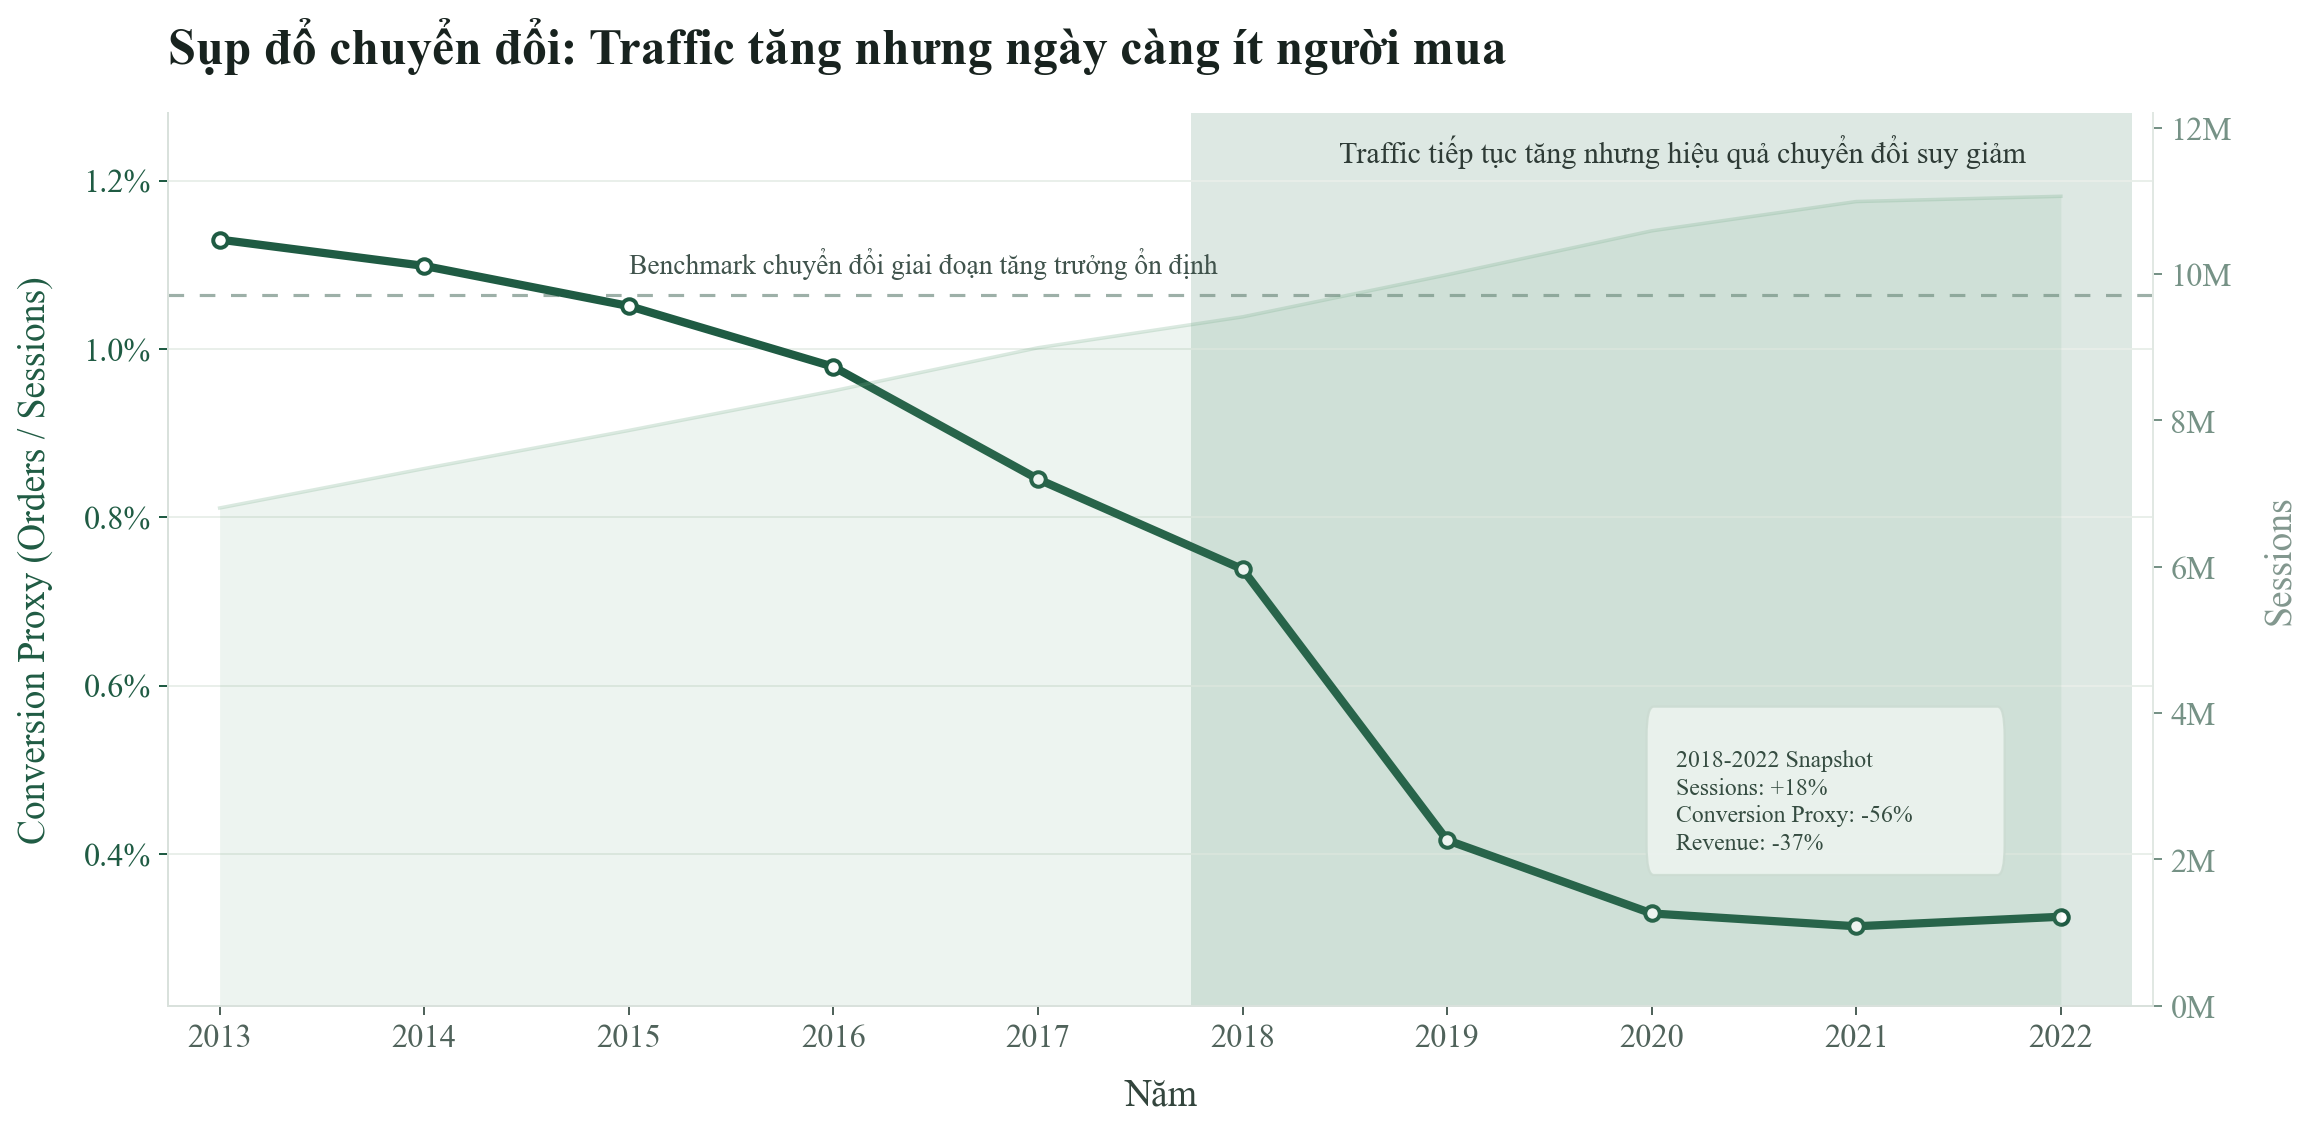

In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import FancyBboxPatch
from matplotlib.ticker import FuncFormatter


ROOT_DIR = Path.cwd().parent
DATA_DIR = ROOT_DIR / "ai_eda" / "datathon-2026-round-1"
OUT_DIR = ROOT_DIR / "ai_eda" / "report_visuals"
OUT_DIR.mkdir(parents=True, exist_ok=True)


traffic = pd.read_csv(DATA_DIR / "web_traffic.csv", parse_dates=["date"])
orders = pd.read_csv(DATA_DIR / "orders.csv", parse_dates=["order_date"])
sales = pd.read_csv(DATA_DIR / "sales.csv", parse_dates=["Date"])

traffic_y = (
    traffic.assign(Year=traffic["date"].dt.year)
    .groupby("Year", as_index=False)["sessions"]
    .sum()
)
orders_y = (
    orders.assign(Year=orders["order_date"].dt.year)
    .groupby("Year", as_index=False)
    .agg(orders=("order_id", "nunique"))
)
sales_y = (
    sales.assign(Year=sales["Date"].dt.year)
    .groupby("Year", as_index=False)
    .agg(revenue=("Revenue", "sum"))
)

annual = (
    traffic_y.merge(orders_y, on="Year", how="inner")
    .merge(sales_y, on="Year", how="left")
    .query("2013 <= Year <= 2022")
    .sort_values("Year")
)
annual["conversion_proxy_pct"] = annual["orders"] / annual["sessions"] * 100
annual["conversion_proxy_3p"] = (
    annual["conversion_proxy_pct"].rolling(3, center=True, min_periods=2).mean()
)
annual["sessions_m"] = annual["sessions"] / 1_000_000



benchmark = annual.loc[
    annual["Year"].between(2013, 2016), "conversion_proxy_pct"
].mean()
start = annual.loc[annual["Year"].eq(2018)].iloc[0]
end = annual.loc[annual["Year"].eq(2022)].iloc[0]
sessions_delta = (end["sessions"] / start["sessions"] - 1) * 100
conversion_delta = (
    end["conversion_proxy_pct"] / start["conversion_proxy_pct"] - 1
) * 100
revenue_delta = (end["revenue"] / start["revenue"] - 1) * 100

plt.rcParams.update(
    {
        "font.family": "Times New Roman",
        "font.size": 13,
        "axes.titleweight": "bold",
        "axes.labelcolor": "#33453d",
        "axes.edgecolor": "#d9e1dc",
        "xtick.color": "#50635b",
        "ytick.color": "#50635b",
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
    }
)

fig, ax = plt.subplots(figsize=(14.5, 8.2), dpi=180)
ax2 = ax.twinx()

forest = "#1f5b43"
sage = "#6FA984"
muted = "#789287"
ink = "#1f2f2a"
grid = "#e8eee9"
highlight = "#dfeae3"

ax.axvspan(2017.75, 2022.35, color="#D8E5DF", alpha=0.85, lw=0, zorder=1)
ax.text(
    2020.15,
    1.215,
    "Traffic tiếp tục tăng nhưng hiệu quả chuyển đổi suy giảm",
    ha="center",
    va="bottom",
    fontsize=12,
    color="#2e3b36",
)

ax2.fill_between(
    annual["Year"].to_numpy(),
    annual["sessions_m"].to_numpy(),
    color="#6FA984",
    alpha=0.12,
    linewidth=0,
    zorder=1,
)
ax2.plot(
    annual["Year"],
    annual["sessions_m"],
    color="#6FA984",
    alpha=0.25,
    linewidth=1.4,
    zorder=2,
)

ax.axhline(
    benchmark,
    color=muted,
    linestyle=(0, (5, 5)),
    linewidth=1.25,
    alpha=0.72,
    zorder=2,
)
ax.text(
    2015,
    benchmark + 0.018,
    "Benchmark chuyển đổi giai đoạn tăng trưởng ổn định",
    color="#40534c",
    fontsize=11,
    va="bottom",
)

ax.plot(
    annual["Year"],
    annual["conversion_proxy_pct"],
    color=forest,
    linewidth=3.3,
    marker="o",
    markersize=5.8,
    markerfacecolor="white",
    markeredgecolor=forest,
    markeredgewidth=1.6,
    zorder=5,
)
# ax.plot(
#     annual["Year"],
#     annual["conversion_proxy_3p"],
#     color=forest,
#     linewidth=1.15,
#     alpha=0.22,
#     zorder=4,
# )

# ax.annotate(
#     "Giai đoạn tăng trưởng ổn định:\ntraffic và chuyển đổi còn đồng pha",
#     xy=(2014.2, annual.loc[annual["Year"].eq(2014), "conversion_proxy_pct"].iloc[0]),
#     xytext=(2013.05, 1.235),
#     fontsize=9.6,
#     color="#33453d",
#     ha="left",
#     va="top",
#     arrowprops=dict(
#         arrowstyle="-",
#         color="#8fa69b",
#         lw=1.0,
#         shrinkA=0,
#         shrinkB=4,
#         connectionstyle="angle3,angleA=0,angleB=90",
#     ),
# )
# ax.annotate(
#     "Điểm bắt đầu suy giảm\nhiệu quả chuyển đổi",
#     xy=(2017, annual.loc[annual["Year"].eq(2017), "conversion_proxy_pct"].iloc[0]),
#     xytext=(2015.95, 0.70),
#     fontsize=9.6,
#     color="#33453d",
#     ha="left",
#     va="top",
#     arrowprops=dict(
#         arrowstyle="-",
#         color="#8fa69b",
#         lw=1.0,
#         shrinkA=0,
#         shrinkB=4,
#         connectionstyle="angle3,angleA=0,angleB=-90",
#     ),
# )
# ax.annotate(
#     "Nhiều traffic hơn nhưng ít buyers \nhơn trên mỗi lượt truy cập",
#     xy=(2019, annual.loc[annual["Year"].eq(2019), "conversion_proxy_pct"].iloc[0]),
#     xytext=(2018.45, 0.3),
#     fontsize=9.6,
#     color="#33453d",
#     ha="left",
#     va="top",
#     arrowprops=dict(
#         arrowstyle="-",
#         color="#8fa69b",
#         lw=1.0,
#         shrinkA=0,
#         shrinkB=4,
#         connectionstyle="angle3,angleA=0,angleB=-90",
#     ),
# )

box_x, box_y, box_w, box_h = 2020, 0.4, 1.7, 0.15
ax.add_patch(
    FancyBboxPatch(
        (box_x, box_y),
        box_w,
        box_h,
        boxstyle="round,pad=0.025,rounding_size=0.035",
        facecolor="white",
        edgecolor="#d9e3dd",
        linewidth=0.9,
        alpha=0.88,
        transform=ax.transData,
        zorder=6,
    )
)

ax.set_xlim(2012.75, 2022.45)
ax.set_ylim(0.22, 1.28)
ax2.set_ylim(0, 12.2)
ax.set_xticks(annual["Year"])
ax.set_ylabel(
    "Conversion Proxy (Orders / Sessions)",
    fontsize=15,
    labelpad=12,
    color=forest,
)
ax2.set_ylabel("Sessions", fontsize=15, labelpad=12, color="#82978e")
ax.set_xlabel("Năm", fontsize=15, labelpad=10, color="#33453d")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.1f}%"))
ax2.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0f}M"))
ax.tick_params(axis="y", colors=forest)
ax2.tick_params(axis="y", colors="#769286")
ax.grid(axis="y", color=grid, linewidth=0.75)
ax.grid(axis="x", visible=False)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_color("#e1e8e3")
ax.spines["left"].set_color("#d9e1dc")
ax.spines["bottom"].set_color("#d9e1dc")

plt.title(
    'Sụp đổ chuyển đổi: Traffic tăng nhưng ngày càng ít người mua',
    loc='left', fontdict={'family': 'Times New Roman', 'fontweight': 'bold', 'color': '#18231F', 'fontsize': 20}, pad=20
)

# fig.text(
#     0.07,
#     0.925,
#     "Sau năm 2018, traffic tiếp tục tăng trong khi hiệu quả chuyển đổi suy giảm liên tục.",
#     ha="left",
#     fontsize=11.2,
#     color="#52665e",
# )
# fig.text(
#     0.07,
#     0.055,
#     "Nguồn: web_traffic.csv, orders.csv, sales.csv | Conversion Proxy = Orders / Sessions | Sessions shown as contextual background",
#     ha="left",
#     fontsize=8.6,
#     color="#7b8d85",
# )

snapshot = (
    "2018-2022 Snapshot\n"
    f"Sessions: {sessions_delta:+.0f}%\n"
    f"Conversion Proxy: {conversion_delta:+.0f}%\n"
    f"Revenue: {revenue_delta:+.0f}%"
)
ax.text(
    box_x + 0.12,
    box_y + box_h - 0.025,
    snapshot,
    fontsize=9.5,
    color="#2e4038",
    ha="left",
    va="top",
    linespacing=1.35,
    zorder=10,
)


fig.tight_layout(rect=[0.055, 0.085, 0.955, 0.875])

for stem in [
    "conversion_efficiency_collapse_executive_dashboard",
    "conversion_collapse_executive_chart",
]:
    fig.savefig(OUT_DIR / f"{stem}.png", dpi=240, bbox_inches="tight")
    fig.savefig(OUT_DIR / f"{stem}.svg", bbox_inches="tight")
annual.to_csv(OUT_DIR / "conversion_efficiency_collapse_annual_metrics.csv", index=False)
plt.show()

